#K-Means Clustering From Scratch

This notebook implements the K-Means clustering algorithm from scratch using NumPy.
The goal is to understand the intuition, math, and iterative optimization process
behind K-Means without relying on libraries like scikit-learn.

# import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Synthetic Dataset

In [2]:
np.random.seed(42)

X = np.vstack([
    np.random.randn(100, 2) + np.array([2, 2]),
    np.random.randn(100, 2) + np.array([-2, -2]),
    np.random.randn(100, 2) + np.array([2, -2])
])

# Visualize Raw Data

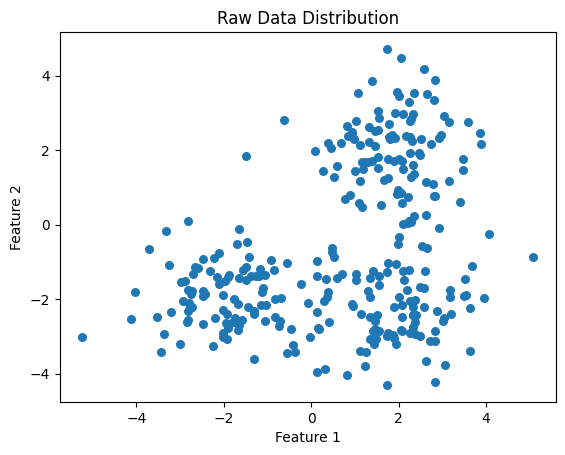

In [3]:
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Raw Data Distribution")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## K-Means Intuition

K-Means works by:
1. Randomly initializing K centroids
2. Assigning each data point to the nearest centroid
3. Updating centroids as the mean of assigned points
4. Repeating until centroids stop moving

The objective is to minimize the **distortion cost function**:

J = average squared distance between points and their assigned centroid

# Centroids

In [4]:
def initialize_centroids(X, K):
    indices = np.random.choice(len(X), K, replace=False)
    return X[indices]

# Distance Calculation

In [5]:
def compute_distances(X, centroids):
    distances = np.zeros((X.shape[0], centroids.shape[0]))

    for i, centroid in enumerate(centroids):
        distances[:, i] = np.linalg.norm(X - centroid, axis=1)

    return distances

# Assign Clusters

In [6]:
def assign_clusters(distances):
    return np.argmin(distances, axis=1)

In [7]:
def update_centroids(X, labels, K):
    new_centroids = np.zeros((K, X.shape[1]))

    for k in range(K):
        new_centroids[k] = X[labels == k].mean(axis=0)

    return new_centroids

# Cost Function

In [8]:
def compute_cost(X, centroids, labels):
    cost = 0
    for k in range(len(centroids)):
        cluster_points = X[labels == k]
        cost += np.sum((cluster_points - centroids[k]) ** 2)
    return cost / len(X)

# K-Means Algorithm

In [9]:
def kmeans(X, K, max_iters=100):
    centroids = initialize_centroids(X, K)
    cost_history = []

    for _ in range(max_iters):
        distances = compute_distances(X, centroids)
        labels = assign_clusters(distances)
        new_centroids = update_centroids(X, labels, K)

        cost = compute_cost(X, new_centroids, labels)
        cost_history.append(cost)

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return centroids, labels, cost_history

In [10]:
K = 3
centroids, labels, cost_history = kmeans(X, K)

# Visualize Clusters

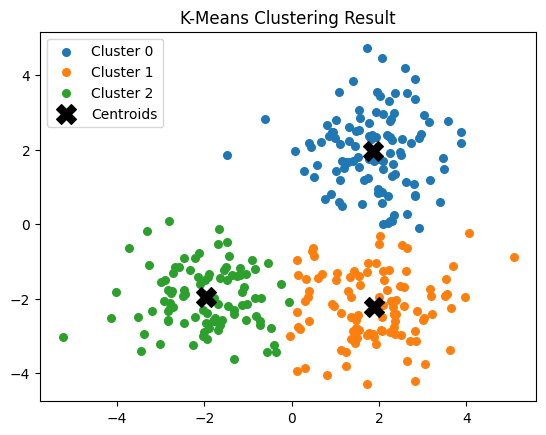

In [11]:
for k in range(K):
    plt.scatter(X[labels == k, 0], X[labels == k, 1], s=30, label=f"Cluster {k}")

plt.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=200, label="Centroids")
plt.legend()
plt.title("K-Means Clustering Result")
plt.show()

# Plot Cost vs Iterations

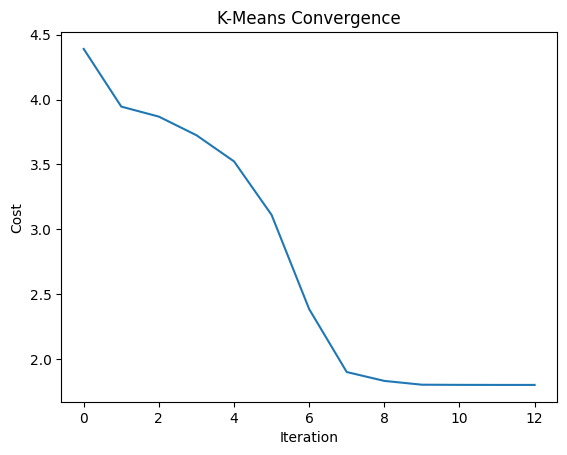

In [12]:
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("K-Means Convergence")
plt.show()

- K-Means is an **iterative optimization algorithm**
- Sensitive to initialization
- Minimizes within-cluster variance
- Requires choosing K manually